In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
### 加载数据
train = pd.read_pickle("train_processed.pkl")
testA = pd.read_pickle("testA_processed.pkl")
print(train.shape, testA.shape)

(118244, 37) (50000, 36)


# 可视化

### price分布

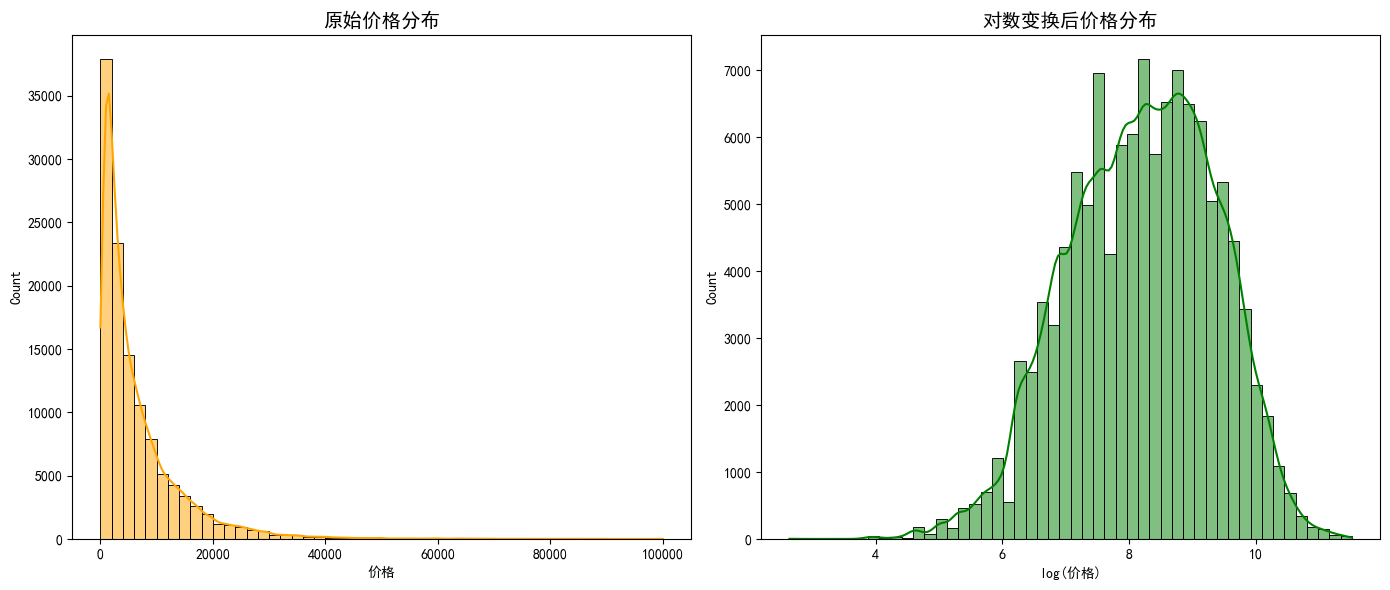

In [4]:
# price原始分布
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
sns.histplot(train['price'], bins=50, kde=True, color='orange')
plt.title('原始价格分布', fontsize=14)
plt.xlabel('价格')

# 对数变换后分布 
plt.subplot(1,2,2)
train['price_log'] = np.log1p(train['price'])
sns.histplot(train['price_log'], bins=50, kde=True, color='green')
plt.title('对数变换后价格分布', fontsize=14)
plt.xlabel('log(价格)')
plt.tight_layout()
plt.show()


### price与特征向量的线性相关性

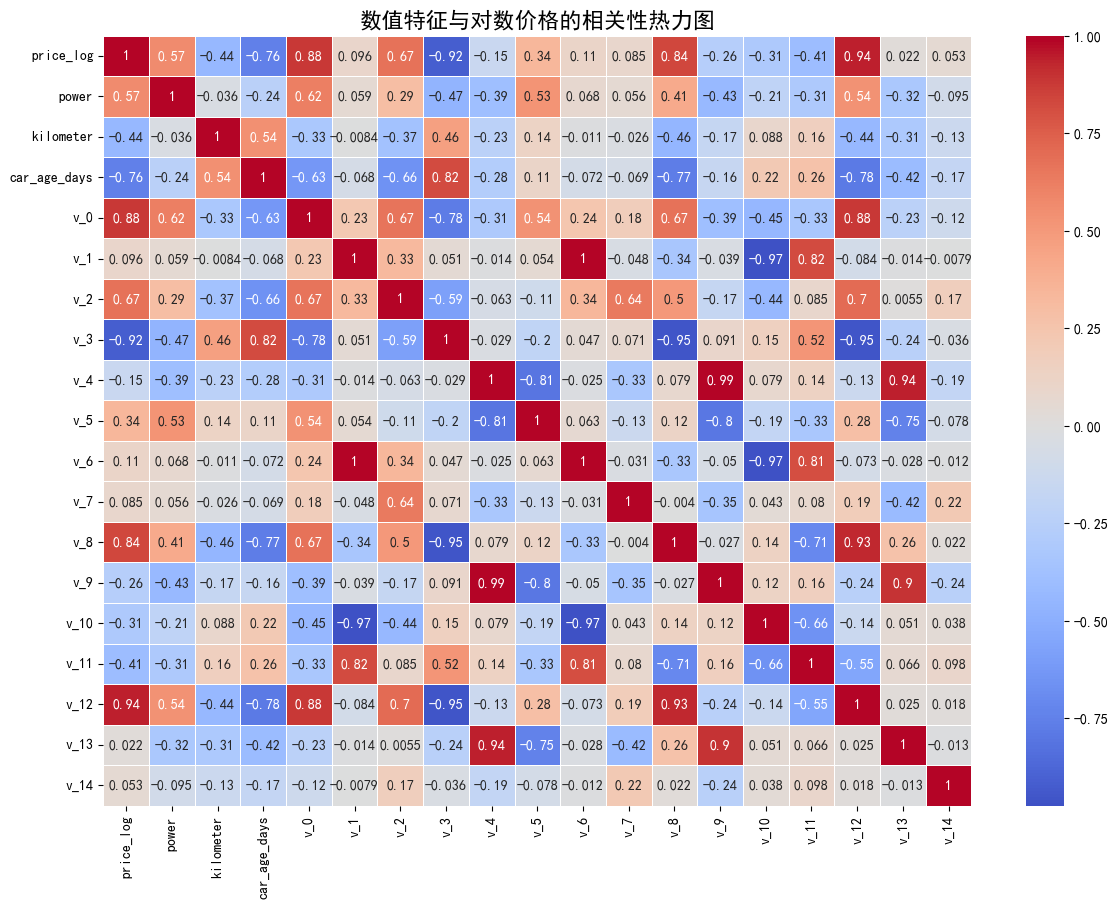

price_log       1.000000
v_12            0.939157
v_3             0.917728
v_0             0.884023
v_8             0.836166
car_age_days    0.755392
v_2             0.673558
power           0.565125
kilometer       0.437551
v_11            0.407353
v_5             0.338804
v_10            0.306965
v_9             0.259115
v_4             0.148246
v_6             0.105467
v_1             0.096158
v_7             0.085116
v_14            0.053461
v_13            0.021949
Name: price_log, dtype: float64


In [15]:
num_features = [
    'price_log', 'power', 'kilometer', 'car_age_days',
    'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5',
    'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14'
]

### 相关性矩阵
corr_matrix = train[num_features].corr()

### 画热力图（特征 + log_price）
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,  
    cmap='coolwarm', 
    linewidths=0.5,
    center=0 
)
plt.title('数值特征与对数价格的相关性热力图', fontsize=16)
plt.show()

### 打印特征与log_price相关性，由高到低(取绝对值)
coeff = corr_matrix['price_log'].abs().sort_values(ascending=False)
print(coeff)

### 特征向量间的线性相关性

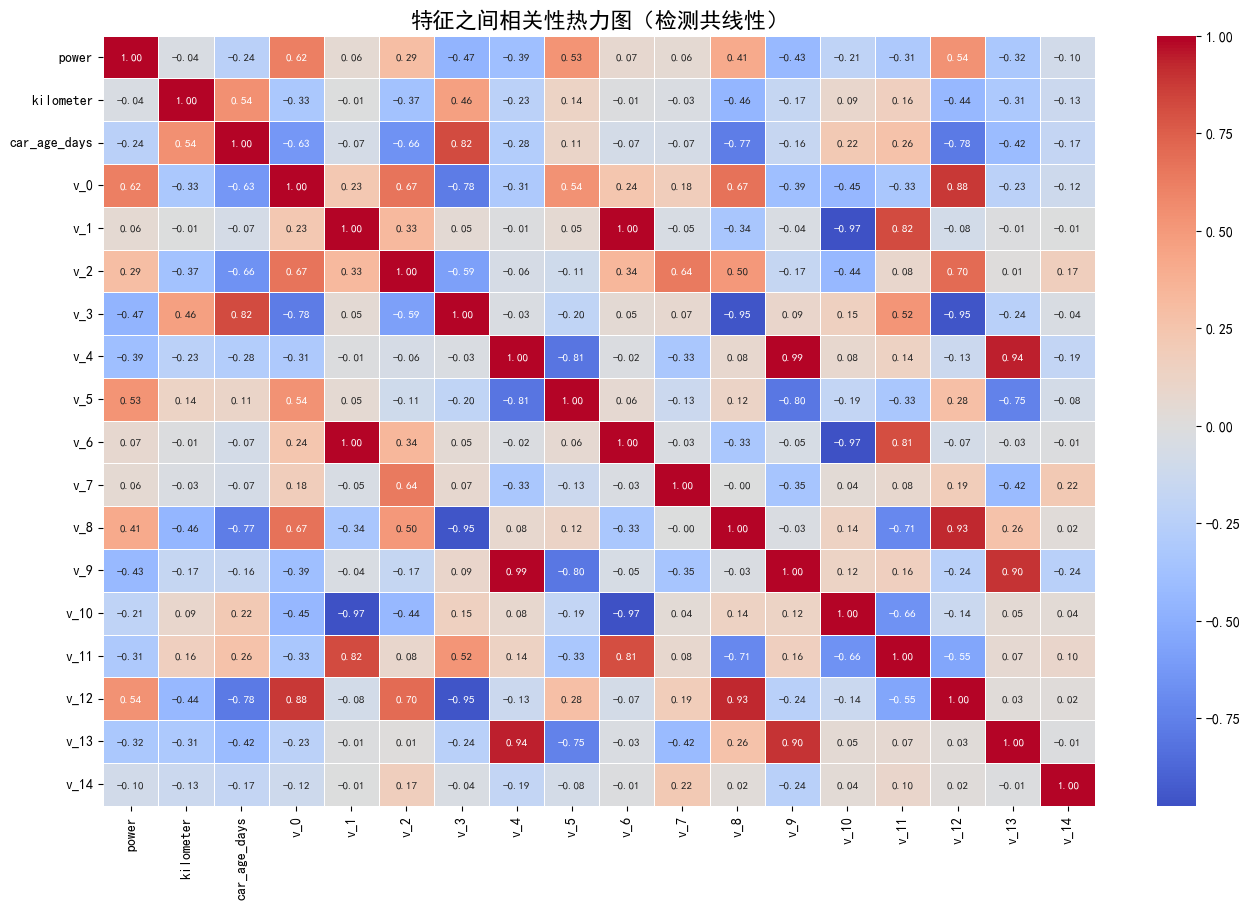

In [7]:
feat_cols = ['power','kilometer','car_age_days','v_0','v_1','v_2','v_3','v_4','v_5','v_6','v_7','v_8','v_9','v_10','v_11','v_12','v_13','v_14']
corr_feat = train[feat_cols].corr()

plt.figure(figsize=(16,10))
sns.heatmap(
    corr_feat,
    annot=True,  
    fmt=".2f",   
    annot_kws={"size": 8},
    cmap='coolwarm', 
    linewidths=0.5,
    center=0  # 让0相关的颜色为中间色，正负相关对比更明显
)
plt.title('特征之间相关性热力图（检测共线性）', fontsize=16)
plt.show()

In [ ]:
# ==============================
# 1) 训练/测试分布偏移图（KDE + ECDF）
# ==============================
num_shift_cols = ['power', 'kilometer', 'car_age_days'] + [f'v_{i}' for i in range(15)]

def _plot_shift_grid(cols, kind='kde', ncols=3):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        tr = train[col].dropna()
        ta = testA[col].dropna()

        if kind == 'kde':
            sns.kdeplot(tr, ax=ax, label='train', linewidth=1.6)
            sns.kdeplot(ta, ax=ax, label='testA', linewidth=1.6)
            if 'testB' in globals():
                tb = testB[col].dropna()
                sns.kdeplot(tb, ax=ax, label='testB', linewidth=1.6)
            ax.set_title(f'{col} KDE')
        else:
            sns.ecdfplot(tr, ax=ax, label='train', linewidth=1.6)
            sns.ecdfplot(ta, ax=ax, label='testA', linewidth=1.6)
            if 'testB' in globals():
                tb = testB[col].dropna()
                sns.ecdfplot(tb, ax=ax, label='testB', linewidth=1.6)
            ax.set_title(f'{col} ECDF')

        ax.legend(loc='best', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print('>>> 分布偏移图：KDE')
_plot_shift_grid(num_shift_cols, kind='kde', ncols=3)

print('>>> 分布偏移图：ECDF')
_plot_shift_grid(num_shift_cols, kind='ecdf', ncols=3)

# ==============================
# 2) 类别特征对价格影响（Top-K + Other）
# ==============================
if 'price_log' not in train.columns:
    train['price_log'] = np.log1p(train['price'])

cat_for_price = ['brand', 'model', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage']
topk_map = {
    'brand': 15,
    'model': 20,
    'bodyType': 10,
    'fuelType': 10,
    'gearbox': 5,
    'notRepairedDamage': 5
}

def _topk_other(series, k):
    s = series.astype(str)
    top = s.value_counts().head(k).index
    return np.where(s.isin(top), s, 'Other')

for col in cat_for_price:
    k = topk_map.get(col, 10)
    tmp = train[[col, 'price_log']].copy()
    tmp[f'{col}_grp'] = _topk_other(tmp[col], k)
    order = tmp[f'{col}_grp'].value_counts().index

    plt.figure(figsize=(12, 4.5))
    sns.boxplot(data=tmp, x=f'{col}_grp', y='price_log', order=order, showfliers=False)
    plt.title(f'{col} 对 price_log 的影响（Top-{k} + Other）')
    plt.xlabel(col)
    plt.ylabel('price_log')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==============================
# 3) 异常值诊断（箱线图 + 分位图）
# ==============================
outlier_cols = ['power', 'car_age_days', 'price_log']

plt.figure(figsize=(14, 4))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=train[col], showfliers=True)
    plt.title(f'{col} 箱线图')
plt.tight_layout()
plt.show()

q_grid = np.linspace(0, 1, 101)
plt.figure(figsize=(14, 4))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    q_vals = train[col].quantile(q_grid)
    plt.plot(q_grid, q_vals, linewidth=1.8)
    plt.title(f'{col} 分位图')
    plt.xlabel('quantile')
    plt.ylabel('value')
plt.tight_layout()
plt.show()

print('>>> 关键分位数（异常值诊断参考）')
display(train[outlier_cols].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).T)

# ==============================
# 4) 缺失机制可视化（缺失率 + 缺失与价格关系）
# ==============================
miss_cols = [c for c in train.columns if c.endswith('_ismissing')]

if len(miss_cols) == 0:
    print('当前训练集没有 *_ismissing 列，无法绘制缺失机制图。')
else:
    miss_rate = train[miss_cols].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=miss_rate.index, y=miss_rate.values, color='steelblue')
    plt.title('训练集各特征缺失率（基于 *_ismissing）')
    plt.ylabel('missing rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    for col in miss_cols:
        plt.figure(figsize=(5.5, 4))
        sns.boxplot(data=train, x=col, y='price_log', showfliers=False)
        plt.title(f'{col} 与 price_log 关系')
        plt.xlabel(f'{col} (0=非缺失, 1=缺失)')
        plt.ylabel('price_log')
        plt.tight_layout()
        plt.show()
